In [36]:
!pip install -q pandas numpy matplotlib seaborn scikit-learn

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import zipfile
import os
import glob

from google.colab import files

import warnings
warnings.filterwarnings("ignore")

In [38]:
uploaded = files.upload()

Saving archive (3).zip to archive (3) (1).zip


In [39]:
zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [40]:
csv_files = glob.glob("dataset/**/*.csv", recursive=True)

print(csv_files)

['dataset/netflix_titles.csv']


In [41]:
csv_file = csv_files[0]

df = pd.read_csv(csv_file)

print("Dataset Loaded Successfully!")

df.head()

Dataset Loaded Successfully!


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [42]:
print(df.shape)

df.info()

(8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [43]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [44]:
df.fillna('', inplace=True)

In [45]:
df = df[['title',
         'director',
         'cast',
         'listed_in',
         'description',
         'type',
         'country',
         'release_year',
         'rating']]

In [46]:
print(df.columns)

Index(['title', 'director', 'cast', 'listed_in', 'description', 'type',
       'country', 'release_year', 'rating'],
      dtype='object')


In [47]:
df['combined_features'] = (
    df['director'] + " " +
    df['cast'] + " " +
    df['listed_in'] + " " +
    df['description']
)

df[['title','combined_features']].head()

,title,combined_features
0,Dick Johnson Is Dead,Kirsten Johnson Documentaries As her father n...
1,Blood & Water,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaba..."
2,Ganglands,"Julien Leclercq Sami Bouajila, Tracy Gotoas, S..."
3,Jailbirds New Orleans,"Docuseries, Reality TV Feuds, flirtations an..."
4,Kota Factory,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam ..."


In [48]:
tfidf = TfidfVectorizer(stop_words='english')

tfidf_matrix = tfidf.fit_transform(df['combined_features'])

print(tfidf_matrix.shape)

(8807, 49941)


In [49]:
cosine_sim = cosine_similarity(tfidf_matrix)

print(cosine_sim.shape)

(8807, 8807)


In [50]:
indices = pd.Series(df.index, index=df['title']).drop_duplicates()

In [51]:
def recommend_movies(title):

    title = title.strip()

    if title not in indices:
        print("Movie not found.")
        return

    idx = indices[title]

    similarity_scores = list(enumerate(cosine_sim[idx]))

    similarity_scores = sorted(
        similarity_scores,
        key=lambda x:x[1],
        reverse=True
    )

    similarity_scores = similarity_scores[1:11]

    print("\nRecommended Movies\n")

    for i, movie in enumerate(similarity_scores):

        index = movie[0]

        print(f"{i+1}. {df.iloc[index]['title']} ({df.iloc[index]['release_year']})")

In [54]:
recommend_movies("Narcos")

recommend_movies("Stranger Things")


Recommended Movies

1. Wild District (2019)
2. El Cartel (2008)
3. El final del paraíso (2019)
4. La Viuda Negra (2016)
5. The Great Heist (2020)
6. Dueños del paraíso (2015)
7. Narcos: Mexico (2020)
8. Sin senos sí hay paraíso (2018)
9. La Reina del Sur (2019)
10. Miss Dynamite (2015)

Recommended Movies

1. Beyond Stranger Things (2017)
2. Prank Encounters (2021)
3. The Umbrella Academy (2020)
4. Anjaan: Special Crimes Unit (2018)
5. Eli (2019)
6. Safe Haven (2013)
7. Homefront (2013)
8. Kiss Me First (2018)
9. Good Witch (2019)
10. Equilibrium (2002)


In [55]:
movie = input("Enter Movie Name : ")

recommend_movies(movie)

Enter Movie Name : Safe Haven

Recommended Movies

1. What's Eating Gilbert Grape (1993)
2. Burlesque (2010)
3. The Autopsy of Jane Doe (2016)
4. An Unfinished Life (2005)
5. Friends from College (2019)
6. Top Grier (2018)
7. Dear John (2010)
8. Results (2015)
9. Junebug (2005)
10. Desire (2017)


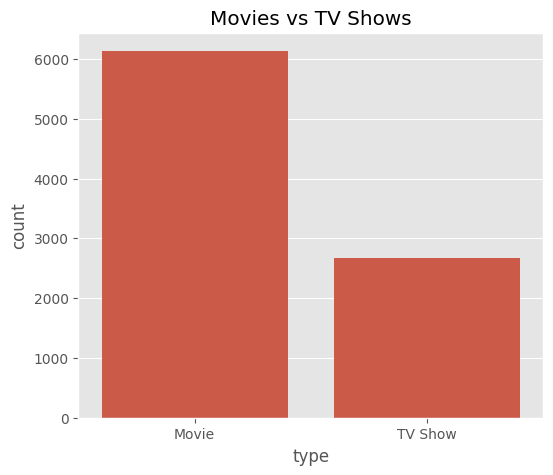

In [56]:
plt.figure(figsize=(6,5))

sns.countplot(data=df, x='type')

plt.title("Movies vs TV Shows")

plt.show()

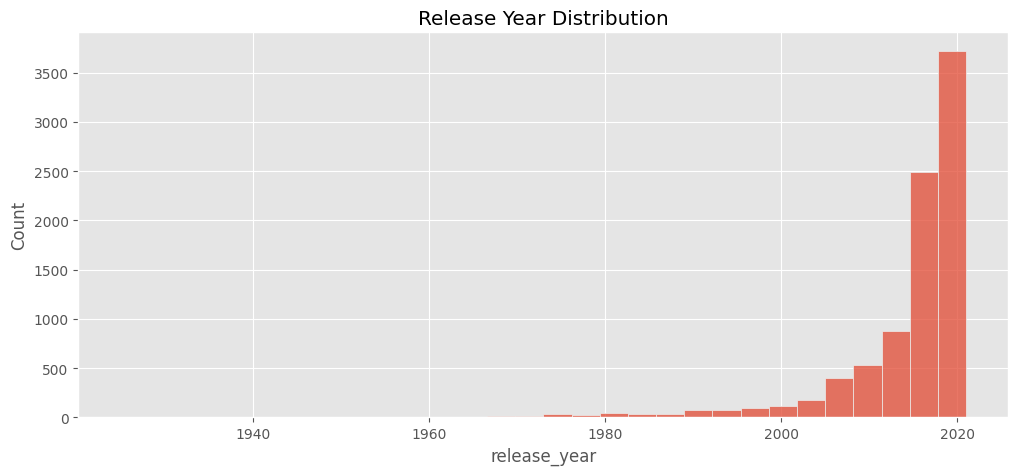

In [57]:
plt.figure(figsize=(12,5))

sns.histplot(df['release_year'], bins=30)

plt.title("Release Year Distribution")

plt.show()

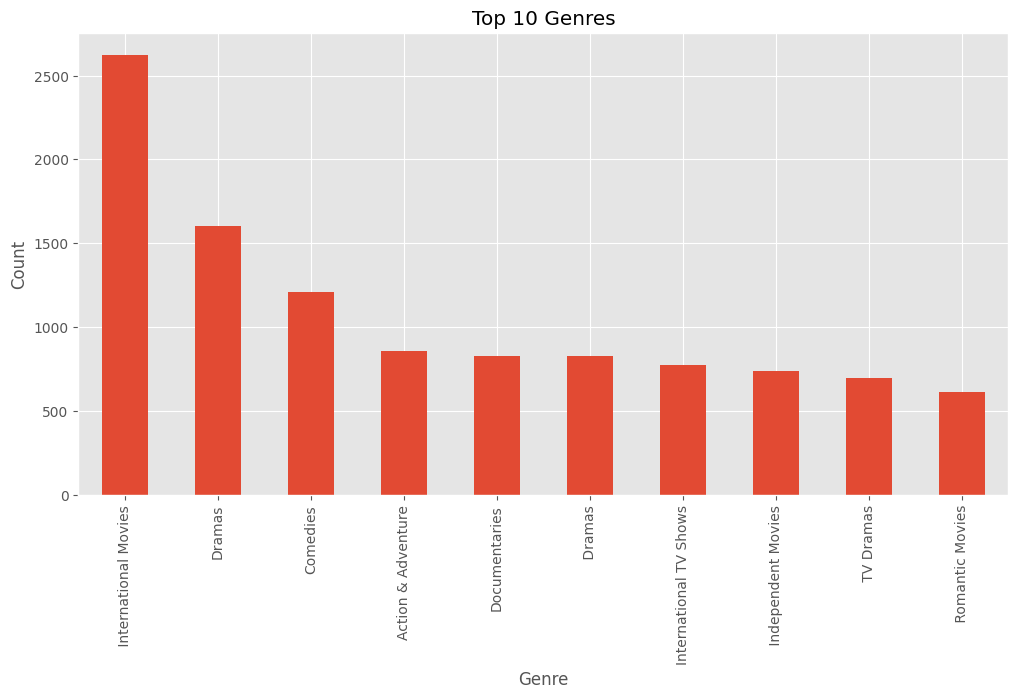

In [58]:
genres = df['listed_in'].str.split(',')

genres = genres.explode()

plt.figure(figsize=(12,6))

genres.value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Genres")

plt.xlabel("Genre")

plt.ylabel("Count")

plt.show()

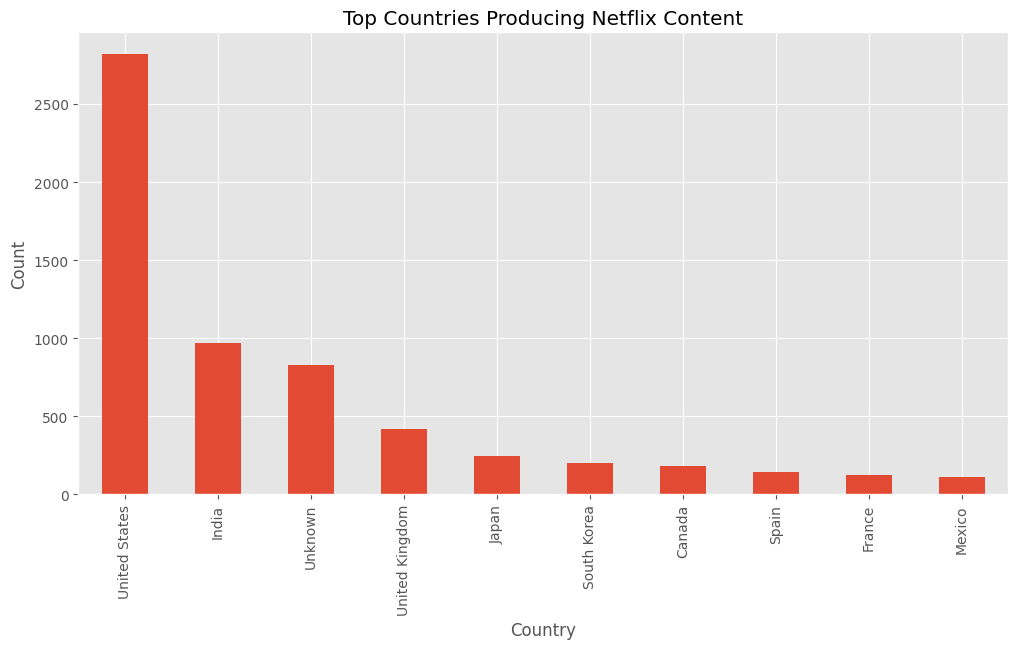

In [59]:
plt.figure(figsize=(12,6))

country = df['country'].replace('', 'Unknown')

country.value_counts().head(10).plot(kind='bar')

plt.title("Top Countries Producing Netflix Content")

plt.xlabel("Country")

plt.ylabel("Count")

plt.show()

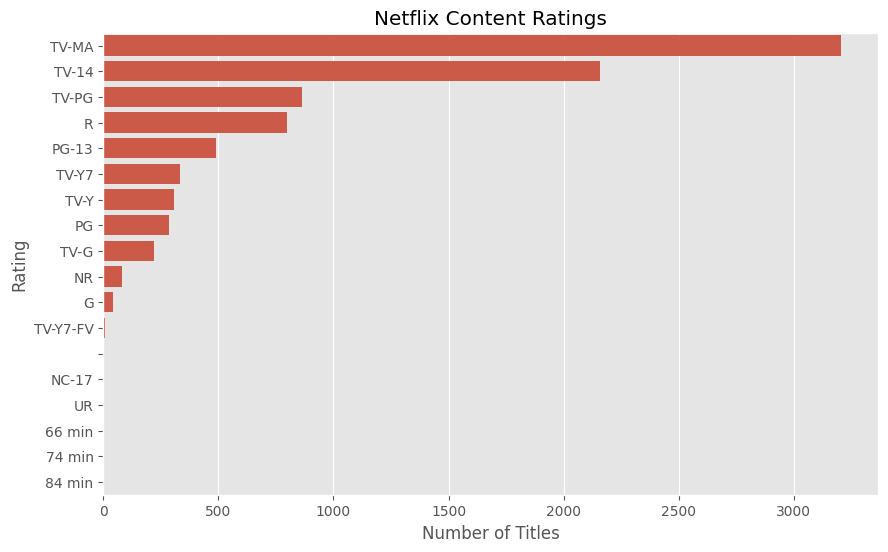

In [60]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    y='rating',
    order=df['rating'].value_counts().index
)

plt.title("Netflix Content Ratings")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.show()

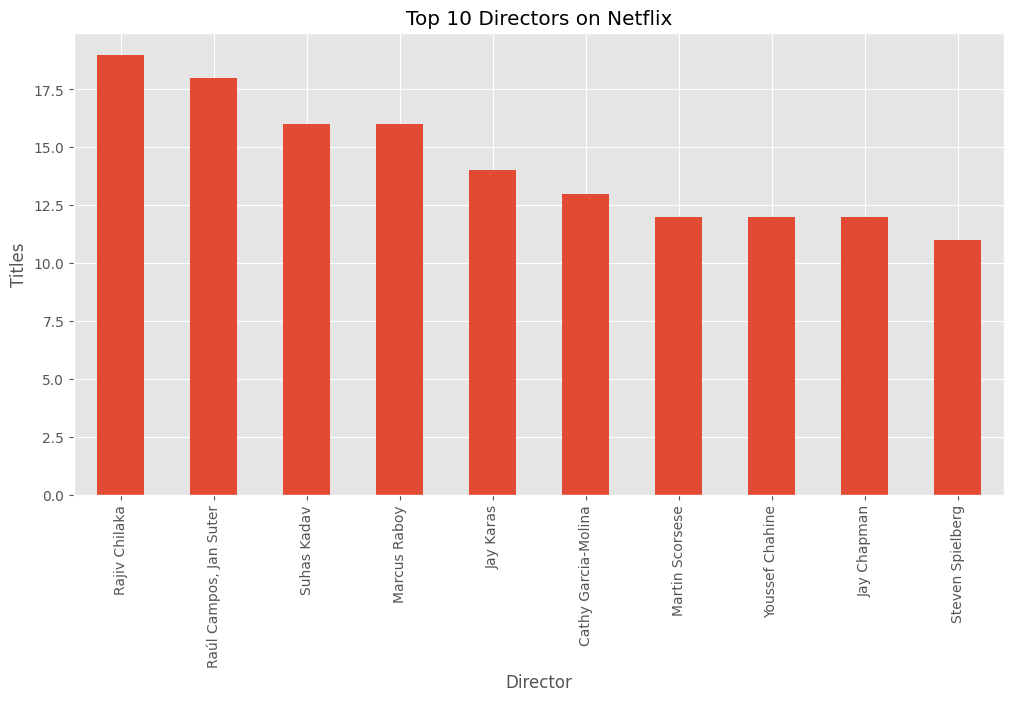

In [61]:
directors = df[df['director'] != '']['director']

plt.figure(figsize=(12,6))

directors.value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Directors on Netflix")

plt.xlabel("Director")

plt.ylabel("Titles")

plt.show()

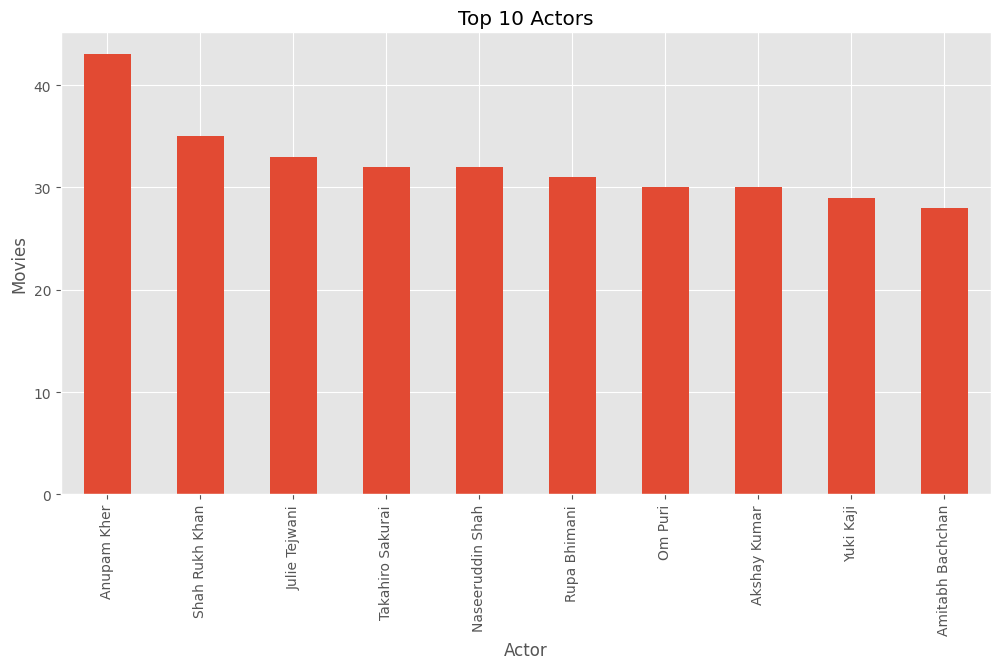

In [62]:
actors = df['cast'].str.split(',')

actors = actors.explode()

actors = actors.str.strip()

actors = actors[actors != '']

plt.figure(figsize=(12,6))

actors.value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Actors")

plt.xlabel("Actor")

plt.ylabel("Movies")

plt.show()

In [63]:
df.to_csv("cleaned_netflix_dataset.csv", index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully


In [64]:
files.download("cleaned_netflix_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [65]:
while True:

    movie = input("\nEnter Movie Name (type 'exit' to stop): ")

    if movie.lower() == 'exit':
        print("Thank You!")
        break

    recommend_movies(movie)


Enter Movie Name (type 'exit' to stop): exit
Thank You!
